# §2.2 Augment dwell data

The raw GPS dwell data cover ~69,000 Class 8 trucks observed by International, Inc. across the continental U.S. in 2023. Before using these observations as a proxy for the 2035 fleet, we verify that the observed vehicles' primary operating-distance mix (short-haul through long-haul) is nationally representative.

The bar chart in **Figure 2c** compares the proportion of observed vehicles in each primary operating-distance class against the Vehicle Inventory and Use Survey (VIUS) reference distribution. Close alignment justifies using the raw data without re-weighting by operating distance. The printed statistics (VMT coverage, vehicle share) give additional context on data scale.

**Generates:** Figure 2b (example-vehicle stop/route map, assembled in QGIS from an exported trajectory), Figure 2c (operating-distance distribution vs VIUS), and appendix Figure A.12 (trip-distance distribution).

## Load modules

In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from shapely import Point

from laurel.models.dwell_sets import DwellSet
from laurel.utils.h3 import H3_CRS, add_geometries
from laurel.utils.time import total_time_units

## Set global variables

In [2]:
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

In [3]:
DAYS_PER_YEAR = 365.25

BTS_VMT = 195758000000 # From https://www.bts.gov/browse-statistical-products-and-data/freight-facts-and-figures/vehicle-miles-traveled-highway, select 2023 as the year and use "combination trucks"
BTS_VEHS = 3324112 # From https://www.bts.gov/browse-statistical-products-and-data/freight-facts-and-figures/number-trucks-locomotives-rail-cars, select 2023 and "combination trucks"

## Load data

In [4]:
%reload_ext kedro.ipython
%reload_kedro --env=scenario_builders/sense_manage --params=data_dir=/scratch/users/passow/laurel/data

[06/11/26 09:07:07] INFO     Using                                                                  ]8;id=772920;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=26000;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=315457;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=393541;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=426488;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=916188;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=122272;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=956450;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:07:10] INFO     Kedro project LAUREL                                                   ]8;id=392572;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=785902;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

                    INFO     Registered line magic 'run_viz'                                        ]8;id=298352;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=728685;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=188160;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=924911;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:07:12] INFO     Kedro project LAUREL                                                   ]8;id=177173;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=5444;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=265833;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=122457;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=692192;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=323164;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [5]:
vehs_lab = catalog.load("vehicles_labelled")

                    INFO     Loading data from vehicles_labelled (FeatherDataset)...           ]8;id=372705;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=254823;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [6]:
adopts = catalog.load("adoption_scenarios")

                    INFO     Loading data from adoption_scenarios (FeatherDataset)...          ]8;id=861217;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=411716;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [7]:
dwells = catalog.load("dwells_with_locations_dask")

[06/11/26 09:07:14] INFO     Loading data from dwells_with_locations_dask (ParquetDataset)...  ]8;id=218211;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=491307;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

## Summary statistics used in text

In [8]:
obs_vmt = dwells["trip_miles"].sum()
obs_vmt = obs_vmt.compute()

obs_veh_years = (total_time_units(vehs_lab["obs_duration"], unit="1d") / DAYS_PER_YEAR).sum()

vehs_heavy = vehs_lab.loc[vehs_lab["vin_gvw"] == 8]
n_vehs_obs = len(vehs_heavy)
annual_vmt = obs_vmt * n_vehs_obs / obs_veh_years

In [9]:
print(f"Number of observed heavy vehicles: {n_vehs_obs}")
print(f"Share of vehicles observed: {round(n_vehs_obs / BTS_VEHS * 100, 2)}%")
print(f"Share of VMT observed: {round(annual_vmt / BTS_VMT * 100, 2)}%")

Number of observed heavy vehicles: 69434
Share of vehicles observed: 2.09%
Share of VMT observed: 2.17%


## Figure 2b: Example vehicle behavior

Selects a representative vehicle trajectory and exports it as a GeoPackage for use in QGIS, which produces **Figure 2b** — a map of the example vehicle's stop locations and routes.

In [10]:
vehs_geo = vehs_lab.copy()
vehs_geo["time_weighted_center"] = gpd.GeoSeries.from_wkb(vehs_geo["time_weighted_center"], crs=H3_CRS)
vehs_geo = gpd.GeoDataFrame(data=vehs_geo, geometry="time_weighted_center")

In [11]:
REF_PT = Point(-71.0964, 42.3493) # Select Boston as the reference point
candidate_vehs = vehs_geo.loc[
    (vehs_geo["total_obs_miles"] > 5000) & \
    (vehs_geo["vin_gvw"] == 8) & \
    (vehs_geo["time_weighted_center"].distance(REF_PT) <= 1) & \
    (vehs_geo["op_radius_miles"] < 150)
].sort_values("primary_op_dist")
candidate_vehs

[06/11/26 09:07:22] WARNING  /tmp/ipykernel_11233/3996383996.py:5: UserWarning: Geometry is in a    ]8;id=809183;file:///home/users/passow/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=825229;file:///home/users/passow/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/warnings.py#112\112]8;;\
                             geographic CRS. Results from 'distance' are likely incorrect. Use                     
                             'GeoSeries.to_crs()' to re-project geometries to a projected CRS                      
                             before this operation.                                                                
                                                                                                                   
                               (vehs_geo["time_weighted_center"].distance(REF_PT) <= 1) & \                        
                                                                                                                   

,veh_type,vin_gvw,gvw_class,obs_time_first,obs_hex_first,obs_time_last,obs_hex_last,total_obs_miles,obs_duration,op_radius_miles,time_weighted_center,primary_op_dist
veh_id,,,,,,,,,,,,
479,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-04-01 16:49:09+00:00,613231750014828543,2023-11-20 22:07:45+00:00,613231750014828543,14155.619253,233 days 05:18:36,88.208837,POINT (-71.28302 42.55821),0-99 Miles
47976,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-04-03 11:39:15+00:00,613231971532799999,2023-11-17 19:32:14+00:00,613231932085370879,18504.677810,228 days 07:52:59,44.529637,POINT (-71.328 41.81498),0-99 Miles
48384,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-04-01 06:39:02+00:00,613231931535917055,2023-11-20 21:45:49+00:00,613231931638677503,11412.264901,233 days 15:06:47,137.679244,POINT (-71.56046 41.77847),0-99 Miles
48437,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-04-06 12:07:03+00:00,613255427989176319,2023-11-20 15:16:38+00:00,613229830466437119,11306.972952,228 days 03:09:35,84.243257,POINT (-71.16489 42.17832),0-99 Miles
48470,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-04-03 10:11:03+00:00,613231961063817215,2023-11-20 10:05:27+00:00,613231960627609599,10134.035872,230 days 23:54:24,41.487002,POINT (-71.22973 42.05092),0-99 Miles
...,...,...,...,...,...,...,...,...,...,...,...,...
43675,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-04-01 02:24:57+00:00,613231926429351935,2023-11-20 19:52:12+00:00,613232048949166079,16441.644519,233 days 17:27:15,146.806638,POINT (-71.82061 42.24903),100-249 Miles
53523,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-06-19 18:46:12+00:00,613232144583491583,2023-11-18 18:09:16+00:00,613231743480102911,7132.381555,151 days 23:23:04,140.411909,POINT (-71.52442 42.90597),100-249 Miles
19069,TRACTOR TRUCK,8,Heavy Duty (Class 8),2023-08-04 14:11:29+00:00,613231747070427135,2023-11-19 14:37:52+00:00,613231747076718591,7214.268903,107 days 00:26:23,85.285508,POINT (-71.40723 42.20245),100-249 Miles


By visually examining the trajectories of these vehicles, we selected vehicle 43675 as our example.

In [12]:
EXAMPLE_VEH = 43675
traj = dwells.loc[EXAMPLE_VEH].compute()
traj = add_geometries(traj, hex_col="hex_id", geom_type="point")
traj["prev_poly"] = traj.groupby("veh_id")["geometry"].shift(1)
traj["trips"] = traj["prev_poly"].shortest_line(traj["geometry"])
traj = traj.drop(columns=["prev_poly"])
traj.rename_geometry(col="dwells", inplace=True)
traj.set_geometry(col="trips")
traj = traj.drop(columns="dwells")

We save out the trajectory for use in QGIS to create map layouts.

In [13]:
catalog.save("example_vehicle_trajectory", traj)

[06/11/26 09:07:24] INFO     Saving data to example_vehicle_trajectory (GeoPackageDataset)...  ]8;id=203355;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=752012;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

## Figure 2c: Operating distance distribution — Our Data vs. VIUS

Generates **Figure 2c**. Bar chart comparing the distribution of primary operating distance classes (short-haul through long-haul) between the GPS-based dataset used in this study and the Vehicle Inventory and Use Survey (VIUS), validating that our sample is nationally representative.

In [14]:
obs_op_dists = vehs_heavy["primary_op_dist"].value_counts(normalize=True)
obs_op_dists.name = "Our Data"

adopts_heavy = adopts.loc[adopts["is_mandate_active"] & (adopts["scenario"] == "Central") & (adopts["year"] == 2025) & (adopts["gvw_class"].isin(["8"]))]
tgt_op_dists = adopts_heavy.groupby("primary_op_dist")["n_vehs_target"].sum() / adopts_heavy["n_vehs_target"].sum()
tgt_op_dists.name = "VIUS"

op_dists = obs_op_dists.to_frame().join(tgt_op_dists)
op_dists = op_dists.melt(var_name="Source", value_name="share", ignore_index=False)
op_dists

,Source,share
primary_op_dist,,
0-99 Miles,Our Data,0.581804
100-249 Miles,Our Data,0.169125
250-499 Miles,Our Data,0.127963
500+ Miles,Our Data,0.121108
0-99 Miles,VIUS,0.645901
100-249 Miles,VIUS,0.11897
250-499 Miles,VIUS,0.093504
500+ Miles,VIUS,0.141625


[06/11/26 09:07:27] INFO     Saving data to primary_operating_distance_distribution            ]8;id=712523;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=345224;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (MatplotlibDataset)...                                                                

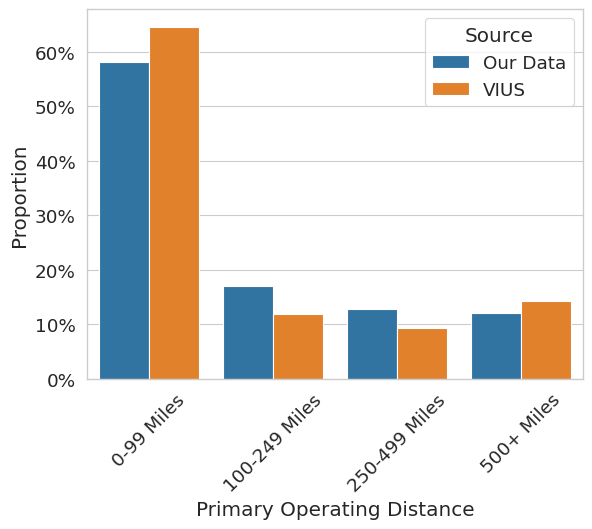

In [15]:
ax = sns.barplot(data=op_dists, x="primary_op_dist", y="share", hue="Source")
ax.set_xlabel("Primary Operating Distance")
ax.set_ylabel("Proportion")

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', labelrotation=45)

catalog.save("primary_operating_distance_distribution", ax.figure)
ax.figure

## Figure A.12: Trip distance distribution by operating distance class

Generates **Figure A.12** in the appendix. ECDF of trip distances (miles) by primary operating distance class, comparing trips with and without optional dwell stops included. Shows that incorporating optional dwells increases effective trip distances, particularly for the short-haul class.

In [16]:
SAMP_FRAC = 0.001

In [17]:
dw = DwellSet(data=dwells, **catalog.load("params:load_dwell_set"))
dw.data["dur_hrs"] = total_time_units(dw.data["dwell_end_time"] - dw.data["dwell_start_time"], unit="1h")

[06/11/26 09:07:28] INFO     Loading data from params:load_dwell_set (MemoryDataset)...        ]8;id=189175;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=754032;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Sorting DwellSet by vehicle and time.                                ]8;id=867638;file:///home/users/passow/laurel/src/laurel/models/dwell_sets.py\dwell_sets.py]8;;\:]8;id=16287;file:///home/users/passow/laurel/src/laurel/models/dwell_sets.py#261\261]8;;\

In [18]:
w_opt_dist_samp = dw.data["trip_miles"].sample(frac=SAMP_FRAC).compute()

In [19]:
dw.data["is_not_opt_stop"] = dw.data["dur_hrs"] > 0.0
dw_orig = dw.accum_masked(
    keep_mask_col="is_not_opt_stop",
    accum_cols="trip_miles",
)
not_opt_dist = dw_orig.data.loc[dw_orig.data["is_not_opt_stop"], "trip_miles"]

In [20]:
not_opt_dist_samp = not_opt_dist.sample(frac=SAMP_FRAC).compute()

In [21]:
dist_df = pd.concat([not_opt_dist_samp.to_frame(), w_opt_dist_samp.to_frame()], keys=["False", "True"], names=["With Optional Dwells"])
dist_df = dist_df.reset_index()

In [22]:
plot_df = dist_df.merge(vehs_lab.loc[:, ["primary_op_dist"]], how="left", on="veh_id")
plot_df = plot_df.dropna(subset="primary_op_dist")
plot_df = plot_df.sort_values("primary_op_dist")

[06/11/26 09:09:47] INFO     Saving data to trip_distance_distribution (MatplotlibDataset)...  ]8;id=410750;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=527855;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

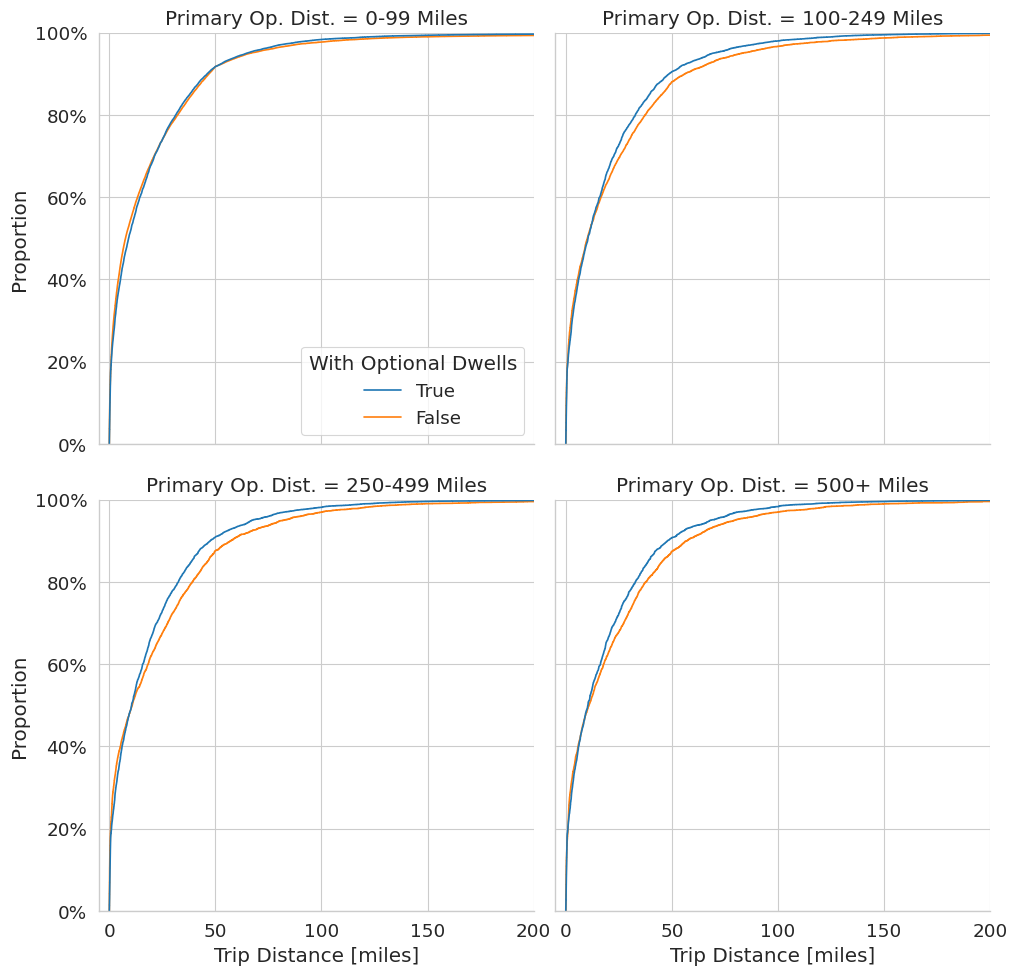

In [23]:
g = sns.displot(
    data=plot_df,
    x="trip_miles",
    hue="With Optional Dwells",
    col="primary_op_dist",
    col_wrap=2,
    kind="ecdf",
    stat="proportion",
    facet_kws={
        "legend_out": False,
    }
)
g = g.set_titles(col_template="Primary Op. Dist. = {col_name}")
g = g.set_axis_labels(x_var="Trip Distance [miles]", y_var="Proportion")
# g._legend.set_title("Primary Operating\nDistance")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlim(left=-5, right=200)

catalog.save("trip_distance_distribution", g.figure)
g.figure